# CV analysis: pyrrole 25C — 2026-05-19 17:46 (v2-success)

Pairs the scope force-sensor log with the potentiostat CV log from the same run.
Two cycles, +1 V → −1 V → +1 V at 5 mV/s (≈800 s/cycle).

- Scope: `scope_log_20260519_174502_cyclic_voltametry_1x_gain_this_one_worked.csv`
- Potentiostat: `data_from_potentiostat/05.19.26-pyrrole-25C-cyclic-volt-v2-success.csv`

Scope and potentiostat were started simultaneously (offset = 0 s). The CSV header's "Date and time measurement" doesn't reflect the actual acquisition-start instant, so we ignore it.

Force conversion on the secondary y-axis is **56.7 mN/V** (1× gain); sample geometry **0.03633 mm × 2.5 mm = 0.0908 mm²**.

In [5]:
# Load both files, align (offset = 0), and filter outliers from the scope log.

import io
import csv
import numpy as np
import pandas as pd

SCOPE_CSV = 'scope_log_20260519_174502_cyclic_voltametry_1x_gain_this_one_worked.csv'
POTEN_CSV = 'data_from_potentiostat/05.19.26-pyrrole-25C-cyclic-volt-v2-success.csv'

DT = 0.2          # potentiostat sample interval (s): 5 mV/s * 0.2 s = 1 mV/step
WINDOW = 41       # MAD outlier-filter rolling window (samples)
K = 5.0           # outlier threshold (multiples of MAD)


# ---- 1. Potentiostat (UTF-16, 6-line header, two scans side-by-side) ----
with open(POTEN_CSV, 'rb') as f:
    text = f.read().decode('utf-16').replace('﻿', '')

lines = text.splitlines()
data_rows = list(csv.reader(io.StringIO('\n'.join(lines[6:]))))
data_rows = [r for r in data_rows if len(r) >= 4 and r[0]]
poten = pd.DataFrame(data_rows, columns=['v1', 'i1_uA', 'v2', 'i2_uA']).astype(float)

n_per_scan = len(poten)
t_scan = np.arange(n_per_scan) * DT
t_exp_full = np.concatenate([t_scan, t_scan + n_per_scan * DT])
v_applied_full = np.concatenate([poten['v1'].values, poten['v2'].values])
exp_total_s = 2 * n_per_scan * DT
print(f'Potentiostat: {n_per_scan} samples/scan, {exp_total_s:.1f} s total')


# ---- 2. Scope log + alignment (offset = 0, scope and potentiostat started together) ----
scope = pd.read_csv(SCOPE_CSV)
scope['t_exp'] = scope['elapsed_s']  # offset = 0
scope_in = scope[(scope['t_exp'] >= 0) & (scope['t_exp'] <= exp_total_s)].copy()
print(f'Scope rows in experiment window: {len(scope_in)} / {len(scope)}')


# ---- 3. Outlier filter (rolling-median + MAD) ----
def mark_outliers(x, window=41, k=5.0):
    s = pd.Series(x)
    med = s.rolling(window, center=True, min_periods=1).median()
    abs_dev = (s - med).abs()
    mad = abs_dev.rolling(window, center=True, min_periods=1).median()
    mad_floor = max(np.nanstd(x) * 1e-3, 1e-9)
    mad = mad.clip(lower=mad_floor)
    return (abs_dev > k * mad).values

mask = mark_outliers(scope_in['ch2_MEAN_V'].values, window=WINDOW, k=K)
print(f'Flagged {mask.sum()} of {len(scope_in)} in-window scope samples '
      f'({mask.sum()/max(len(scope_in),1)*100:.2f}%) as outliers.')
scope_clean = scope_in.loc[~mask].copy()


# ---- 4. Map scope samples to applied voltage + cycle index ----
scope_clean['v_applied'] = np.interp(scope_clean['t_exp'].values, t_exp_full, v_applied_full)
scope_clean['cycle'] = (scope_clean['t_exp'].values >= n_per_scan * DT).astype(int)
print('Cycle 1 scope rows:', (scope_clean['cycle'] == 0).sum())
print('Cycle 2 scope rows:', (scope_clean['cycle'] == 1).sum())
scope_clean.head()

Potentiostat: 4034 samples/scan, 1613.6 s total
Scope rows in experiment window: 3336 / 3336
Flagged 14 of 3336 in-window scope samples (0.42%) as outliers.
Cycle 1 scope rows: 1667
Cycle 2 scope rows: 1655


,elapsed_s,timestamp,ch1_MEAN_V,ch2_MEAN_V,t_exp,v_applied,cycle
0,0.4727,2026-05-19T17:45:03.351875,0.0,2.385850,0.4727,0.997671,0
1,0.9508,2026-05-19T17:45:03.830051,0.0,2.384272,0.9508,0.995293,0
2,1.4548,2026-05-19T17:45:04.333954,0.0,2.382594,1.4548,0.992812,0
3,1.9189,2026-05-19T17:45:04.798071,0.0,2.381064,1.9189,0.990533,0
4,2.4037,2026-05-19T17:45:05.282897,0.0,2.379651,2.4037,0.988073,0


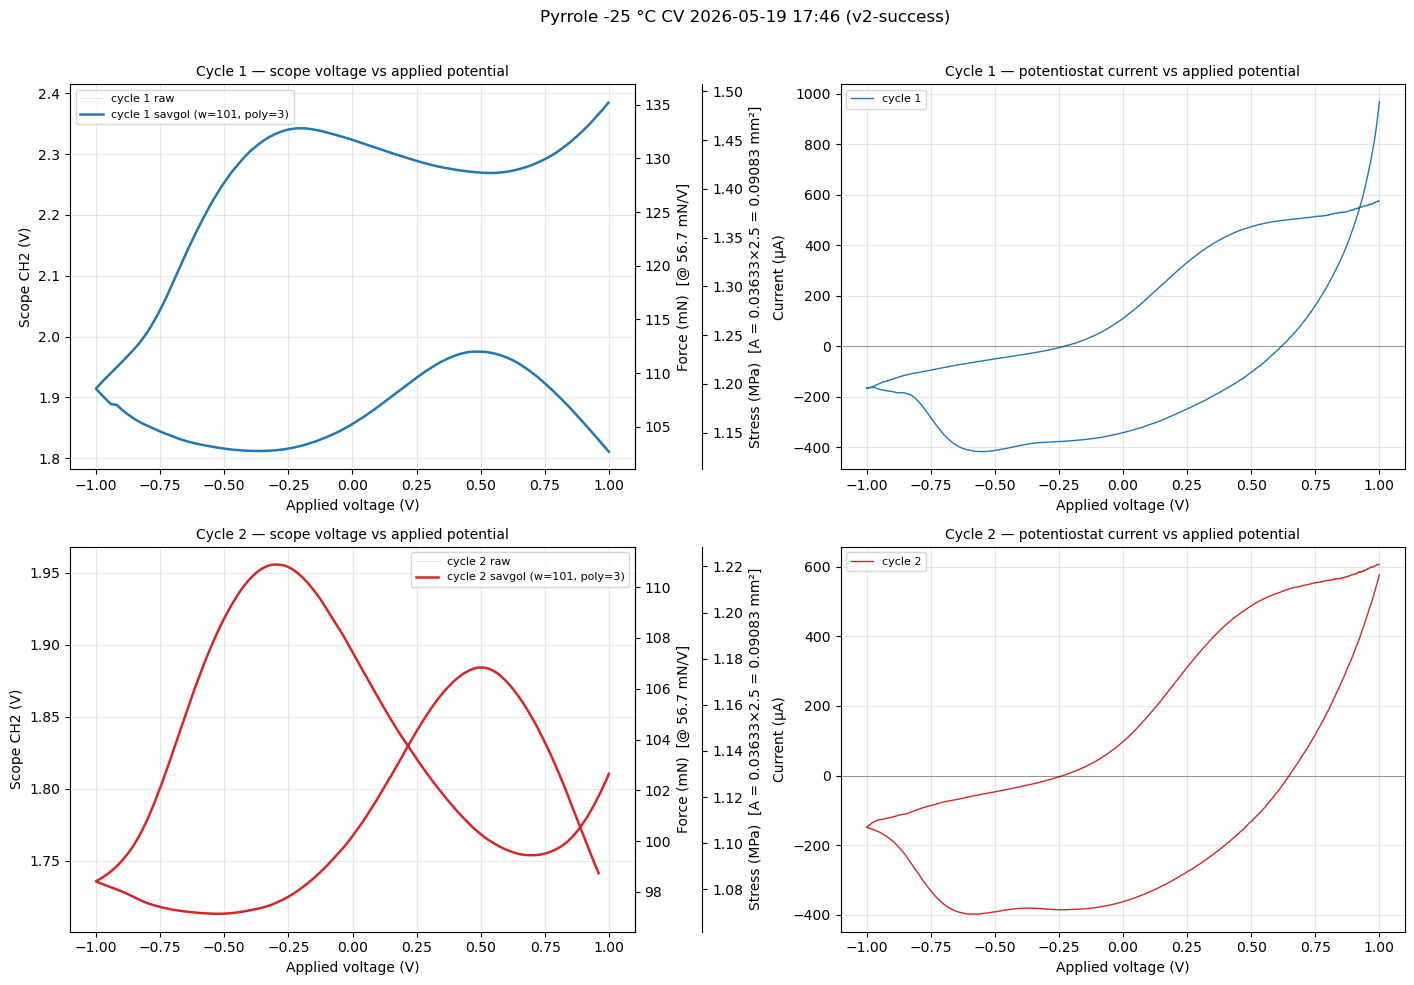

Stress conversion: 0.6242 MPa per scope-V


In [6]:
# Four-panel plot: rows = cycles (1, 2); columns = (scope voltage with force/stress axes, potentiostat current).
# All x-axes are applied voltage from the potentiostat.

import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# --- Sample geometry / calibration ---
FORCE_GAIN_MN_PER_V = 56.7
THICKNESS_MM = 0.03633333333
WIDTH_MM = 2.5
AREA_MM2 = THICKNESS_MM * WIDTH_MM   # 0.0908 mm^2
# Stress: 1 mN/mm^2 == 1 kPa == 1e-3 MPa
STRESS_PER_V_MPA = FORCE_GAIN_MN_PER_V / AREA_MM2 / 1000.0  # MPa per scope-V

CYCLE_COLORS = ['#1f77b4', '#d62728']  # cycle 1 blue, cycle 2 red

SMOOTH_WINDOW = 101
SAVGOL_POLY = 3
RAW_ALPHA = 0.20


def savgol_per_cycle(df, value_col, window=101, poly=3):
    out = pd.Series(np.nan, index=df.index)
    for cyc, sub in df.groupby('cycle'):
        sub = sub.sort_values('t_exp')
        y = sub[value_col].values
        n = len(y)
        if n < 3:
            out.loc[sub.index] = y
            continue
        w = min(window, n)
        if w % 2 == 0:
            w -= 1
        sm = savgol_filter(y, window_length=w, polyorder=poly) if w > poly else y
        out.loc[sub.index] = sm
    return out


scope_clean['ch2_smooth'] = savgol_per_cycle(
    scope_clean, 'ch2_MEAN_V', window=SMOOTH_WINDOW, poly=SAVGOL_POLY,
)


def plot_voltage_panel(ax, sub, color, label):
    ax.plot(sub['v_applied'], sub['ch2_MEAN_V'],
            color=color, lw=0.6, alpha=RAW_ALPHA, label=f'{label} raw')
    ax.plot(sub['v_applied'], sub['ch2_smooth'],
            color=color, lw=1.8,
            label=f'{label} savgol (w={SMOOTH_WINDOW}, poly={SAVGOL_POLY})')
    ax.set_xlabel('Applied voltage (V)')
    ax.set_ylabel('Scope CH2 (V)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)
    # Force axis (right)
    ax_f = ax.secondary_yaxis(
        'right',
        functions=(lambda v: v * FORCE_GAIN_MN_PER_V,
                   lambda mn: mn / FORCE_GAIN_MN_PER_V),
    )
    ax_f.set_ylabel(f'Force (mN)  [@ {FORCE_GAIN_MN_PER_V} mN/V]')
    # Stress axis (offset right)
    ax_s = ax.secondary_yaxis(
        1.12,
        functions=(lambda v: v * STRESS_PER_V_MPA,
                   lambda mpa: mpa / STRESS_PER_V_MPA),
    )
    ax_s.set_ylabel(
        f'Stress (MPa)  [A = {THICKNESS_MM:.5f}×{WIDTH_MM} = {AREA_MM2:.5f} mm²]'
    )


fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ---- Cycle 1 ----
sub1 = scope_clean[scope_clean['cycle'] == 0].sort_values('t_exp')
plot_voltage_panel(axes[0, 0], sub1, CYCLE_COLORS[0], 'cycle 1')
axes[0, 0].set_title('Cycle 1 — scope voltage vs applied potential', fontsize=10)

axes[0, 1].plot(poten['v1'], poten['i1_uA'], color=CYCLE_COLORS[0], lw=1.0, label='cycle 1')
axes[0, 1].set_xlabel('Applied voltage (V)')
axes[0, 1].set_ylabel('Current (µA)')
axes[0, 1].set_title('Cycle 1 — potentiostat current vs applied potential', fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(0, color='k', lw=0.5, alpha=0.5)
axes[0, 1].legend(loc='best', fontsize=8)

# ---- Cycle 2 ----
sub2 = scope_clean[scope_clean['cycle'] == 1].sort_values('t_exp')
plot_voltage_panel(axes[1, 0], sub2, CYCLE_COLORS[1], 'cycle 2')
axes[1, 0].set_title('Cycle 2 — scope voltage vs applied potential', fontsize=10)

axes[1, 1].plot(poten['v2'], poten['i2_uA'], color=CYCLE_COLORS[1], lw=1.0, label='cycle 2')
axes[1, 1].set_xlabel('Applied voltage (V)')
axes[1, 1].set_ylabel('Current (µA)')
axes[1, 1].set_title('Cycle 2 — potentiostat current vs applied potential', fontsize=10)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(0, color='k', lw=0.5, alpha=0.5)
axes[1, 1].legend(loc='best', fontsize=8)

fig.suptitle('Pyrrole -25 °C CV 2026-05-19 17:46 (v2-success)', fontsize=12)
fig.tight_layout(rect=[0, 0, 0.95, 0.97])
plt.show()

print(f'Stress conversion: {STRESS_PER_V_MPA:.4f} MPa per scope-V')